## PRESTIGE STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

prestige=pd.read_csv('../stock_data/prestige.csv') ## so it can be small letter. This is cool.
prestige=prestige.drop(columns=['high_price','low_price'])
prestige.rename(columns={'trade_date':'date'},inplace=True)
prestige['date']=pd.to_datetime(prestige['date'])
prestige['month']=prestige['date'].dt.month
prestige['quarter']=prestige['date'].dt.quarter
prestige['year']=prestige['date'].dt.year

prestige

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,81316,PRESTIGE,2018-09-11,0.48,0.48,0,2026-04-08T03:07:53.572062+00:00,9,3,2018
1,81418,PRESTIGE,2018-09-12,0.48,0.48,0,2026-04-08T03:07:56.190409+00:00,9,3,2018
2,81520,PRESTIGE,2018-09-13,0.48,0.48,130220,2026-04-08T03:07:58.529226+00:00,9,3,2018
3,81622,PRESTIGE,2018-09-14,0.48,0.48,0,2026-04-08T03:08:00.944137+00:00,9,3,2018
4,81724,PRESTIGE,2018-09-17,0.52,0.52,166422,2026-04-08T03:08:05.572353+00:00,9,3,2018
...,...,...,...,...,...,...,...,...,...,...
1851,298119,PRESTIGE,2026-07-13,1.46,1.46,814746,2026-07-13T15:10:02.995074+00:00,7,3,2026
1852,298557,PRESTIGE,2026-07-14,1.45,1.45,1547127,2026-07-14T15:10:03.094441+00:00,7,3,2026
1853,298995,PRESTIGE,2026-07-15,1.45,1.45,737984,2026-07-15T15:10:03.078609+00:00,7,3,2026
1854,299433,PRESTIGE,2026-07-16,1.45,1.45,2475232,2026-07-16T15:10:03.113936+00:00,7,3,2026


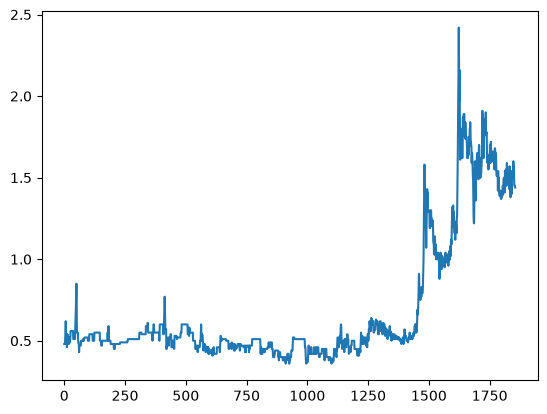

In [2]:
import matplotlib.pyplot as plt

plt.plot(prestige['close_price'])
plt.show()

In [3]:
prestige_end_month_df = (
    prestige
    .sort_values("date")
    .groupby(prestige["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

prestige_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,82642,PRESTIGE,2018-09-28,0.54,0.54,1637124,2026-04-08T03:08:29.283021+00:00,9,3,2018
1,84784,PRESTIGE,2018-10-31,0.56,0.56,10000,2026-04-08T03:09:32.658485+00:00,10,4,2018
2,86824,PRESTIGE,2018-11-30,0.55,0.55,20,2026-04-08T03:10:32.706086+00:00,11,4,2018
3,88350,PRESTIGE,2018-12-31,0.50,0.50,796708,2026-04-08T03:11:26.963749+00:00,12,4,2018
4,90390,PRESTIGE,2019-01-31,0.52,0.52,61103,2026-04-08T03:12:45.452606+00:00,1,1,2019
...,...,...,...,...,...,...,...,...,...,...
90,35356,PRESTIGE,2026-03-31,1.53,1.53,1999013,2026-03-31T15:00:02.085058+00:00,3,1,2026
91,281182,PRESTIGE,2026-04-30,1.39,1.39,864265,2026-04-30T15:00:02.170664+00:00,4,2,2026
92,284248,PRESTIGE,2026-05-29,1.59,1.59,987329,2026-05-29T15:00:02.455558+00:00,5,2,2026
93,294176,PRESTIGE,2026-06-30,1.54,1.54,2406469,2026-06-30T15:10:03.08168+00:00,6,2,2026


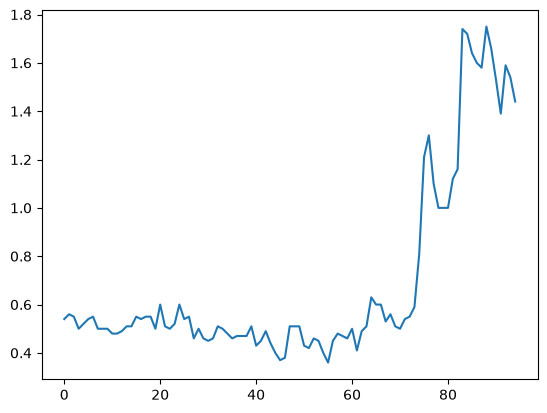

In [4]:
plt.plot(prestige_end_month_df['close_price'])
plt.show()

In [5]:
prestige_end_month_df['returns']=prestige_end_month_df['close_price'].pct_change()*100
prestige_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,82642,PRESTIGE,2018-09-28,0.54,0.54,1637124,2026-04-08T03:08:29.283021+00:00,9,3,2018,NaN
1,84784,PRESTIGE,2018-10-31,0.56,0.56,10000,2026-04-08T03:09:32.658485+00:00,10,4,2018,3.703704
2,86824,PRESTIGE,2018-11-30,0.55,0.55,20,2026-04-08T03:10:32.706086+00:00,11,4,2018,-1.785714
3,88350,PRESTIGE,2018-12-31,0.50,0.50,796708,2026-04-08T03:11:26.963749+00:00,12,4,2018,-9.090909
4,90390,PRESTIGE,2019-01-31,0.52,0.52,61103,2026-04-08T03:12:45.452606+00:00,1,1,2019,4.000000
...,...,...,...,...,...,...,...,...,...,...,...
90,35356,PRESTIGE,2026-03-31,1.53,1.53,1999013,2026-03-31T15:00:02.085058+00:00,3,1,2026,-7.831325
91,281182,PRESTIGE,2026-04-30,1.39,1.39,864265,2026-04-30T15:00:02.170664+00:00,4,2,2026,-9.150327
92,284248,PRESTIGE,2026-05-29,1.59,1.59,987329,2026-05-29T15:00:02.455558+00:00,5,2,2026,14.388489
93,294176,PRESTIGE,2026-06-30,1.54,1.54,2406469,2026-06-30T15:10:03.08168+00:00,6,2,2026,-3.144654


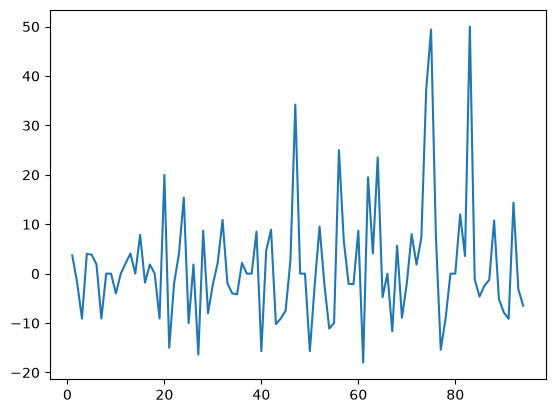

In [6]:
plt.plot(prestige_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(prestige_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-6.935961798605344), np.float64(1.0545102001974755e-09), 2, 91, {'1%': np.float64(-3.50434289821397), '5%': np.float64(-2.8938659630479413), '10%': np.float64(-2.5840147047458037)}, np.float64(647.5460841371295))
stationary


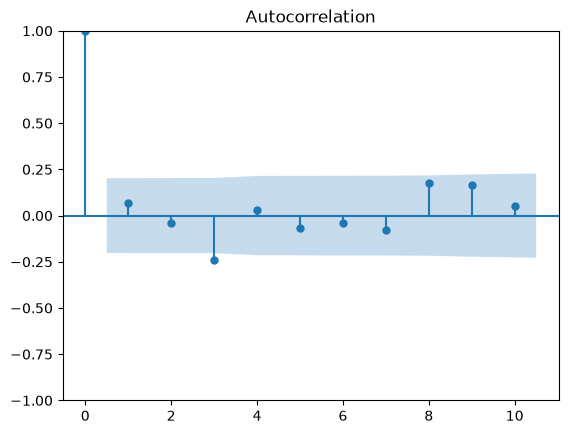

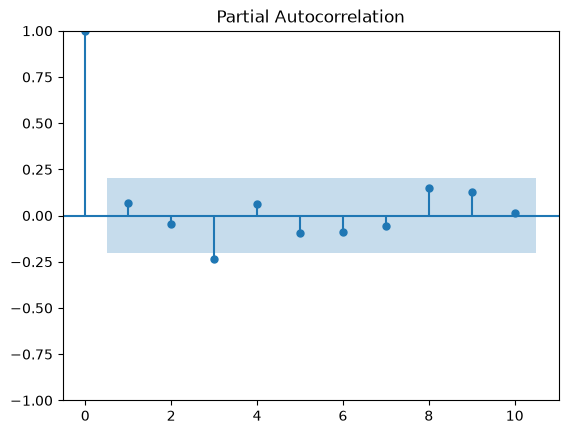

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(prestige_end_month_df['returns'].dropna(), lags=10)
plot_pacf(prestige_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=prestige_end_month_df['close_price'][:-10]
test=prestige_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -250.7288961038961]
[0, 0, 0, 0, 0, 1, -84.19733585537368]
[0, 0, 0, 0, 0, 2, -40.318967562055015]
[0, 0, 0, 0, 1, 0, -33.65401785714285]
[0, 0, 0, 0, 1, 1, -20.093758911054547]
[0, 0, 0, 0, 1, 2, -19.371797751918486]
[0, 0, 0, 0, 2, 0, -12.849431818181813]
[0, 0, 0, 0, 2, 1, -13.155975593324728]
[0, 0, 0, 0, 2, 2, -13.70919871870938]
[0, 0, 0, 1, 0, 0, -40.143516253743904]
[0, 0, 0, 1, 0, 1, -29.751774883203183]
[0, 0, 0, 1, 0, 2, -34.9717369897789]
[0, 0, 0, 1, 1, 0, -19.338569475222283]
[0, 0, 0, 1, 1, 1, -18.79683647638849]
[0, 0, 0, 1, 1, 2, -18.73264468837178]
[0, 0, 0, 1, 2, 0, -13.295194968098368]
[0, 0, 0, 1, 2, 1, -13.616283605495646]
[0, 0, 0, 1, 2, 2, -13.91272319145385]
[0, 0, 0, 2, 0, 0, -32.35521787569516]
[0, 0, 0, 2, 0, 1, -31.60515983231791]
[0, 0, 0, 2, 0, 2, -29.699806885140315]
[0, 0, 0, 2, 1, 0, -18.66470021230321]
[0, 0, 0, 2, 1, 1, -18.61253294245059]
[0, 0, 0, 2, 1, 2, -18.961970634539075]
[0, 0, 0, 2, 2, 0, -13.677959158557641]
[0, 0, 0, 2, 

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
663,2,2,0,1,2,0,-570.037373
420,1,2,0,1,2,0,-567.283375
654,2,2,0,0,2,0,-554.325215
411,1,2,0,0,2,0,-551.439442
664,2,2,0,1,2,1,-422.529653
...,...,...,...,...,...,...,...
163,0,2,0,0,0,1,0.054616
171,0,2,0,1,0,0,0.081650
162,0,2,0,0,0,0,0.204545
176,0,2,0,1,1,2,0.396976


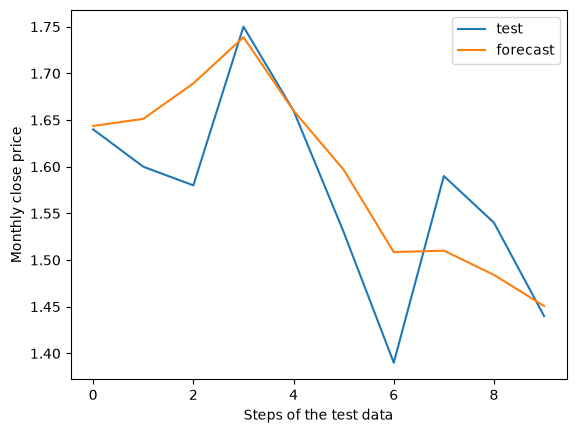

r2_score:  0.5655752837899168
rmse:  0.06543462388496307
description:  count    95.000000
mean      0.691684
std       0.393029
min       0.360000
25%       0.475000
50%       0.510000
75%       0.600000
max       1.750000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=prestige_end_month_df['close_price'][:-10]
y_test=prestige_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(0,2,0), 
seasonal_order=(0,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', prestige_end_month_df.close_price.describe())

This is good.